# IAELPML Assignment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

## TASK 1
Consider the joint distribution $ p(X, Y) $:

$$
\begin{array}{c|ccccc}
  & x=1 & x=2 & x=3 & x=4 & x=5 \\
\hline
y=1 & \frac{1}{10} & \frac{1}{10} & \frac{1}{20} & \frac{1}{5} & \frac{1}{10} \\
y=2 & 0 & \frac{1}{20} & \frac{1}{10} & \frac{1}{20} & \frac{1}{20} \\
y=3 & \frac{1}{20} & \frac{1}{20} & 0 & \frac{1}{10} & 0 \\
\end{array}
$$

For all calculations, use **log base 2**.

### Questions:
1. What is the joint entropy $H(X, Y)$?
2. What are the marginal entropies $H(X)$ and $H(Y)$?
3. Compute $H(X | Y = 3)$.
4. Compute $H(X | Y)$.
5. Compare $H(X, Y)$ with $H(X) + H(Y)$. Are they equal? Why or why not?
6. Calculate the Normalized Mutual Information (NMI)




In [5]:
p_xy = np.array([[1/10, 1/10,1/20,1/5,1/10],
                 [0, 1/20, 1/10,1/20,1/20],
                 [1/20,1/20,0,1/10,0]])

In [9]:
print("H(X,Y):", -np.nansum(p_xy * np.log( p_xy, where = p_xy!=0 )))

H(X,Y): 2.37189981105004


In [11]:
## Para las entropías marginales, en primer lugar calculamos las distribuciones marginales:
p_x=p_xy.sum(axis=0)
p_y=p_xy.sum(axis=1)
#Calculamos ahora las entropías
print("H(X):",-np.nansum(p_x * np.log( p_x, where = p_x!=0 )) )
print("H(Y):",-np.nansum(p_y * np.log( p_y, where = p_y!=0 )) )

H(X): 1.543029319260004
H(Y): 0.9972715231823841


In [15]:
#Conditional Entropy
p_x_given_y = p_xy / p_y[:, None]
conditional_entropy_3 = -np.nansum(p_x_given_y * np.log(p_x_given_y, where = (p_x_given_y != 0)), axis=1)
print("H(X|Y=3):",conditional_entropy_3[2])

H(X|Y=3): 1.0397207708399179


In [17]:
print("H(X,Y):", -np.nansum(p_xy * np.log( p_xy, where = p_xy!=0 )))
print("H(X)+H(Y):",-np.nansum(p_x * np.log( p_x, where = p_x!=0 )) + -np.nansum(p_y * np.log( p_y, where = p_y!=0 )))


H(X,Y): 2.37189981105004
H(X)+H(Y): 2.540300842442388


H(X) + H(Y) > H(X,Y). Dado que I(X;Y) = H(X) + H(Y)-H(X,Y), entonces se tiene que I(X;Y) > 0 y por lo tanto, se deduce que las variables aleatorias X e Y no son independientes.

In [24]:
I_XY = np.nansum(p_xy * np.log( p_xy, where = p_xy!=0 )) -np.nansum(p_x * np.log( p_x, where = p_x!=0 )) - np.nansum(p_y * np.log( p_y, where = p_y!=0 ))
H_X = -np.nansum(p_x * np.log( p_x, where = p_x!=0 ))
H_Y = -np.nansum(p_y * np.log( p_y, where = p_y!=0 ))
print("NMI:", I_XY/min(H_X,H_Y))

NMI: 0.16886176680846665


## TASK 2 

Now, consider the dataset `multi_class_classification.csv` with two input variables ($X_1, X_2$) and a multi-class output $Y$ with three classes ($Y \in \{0, 1, 2\}$). Write a **Softmax Regression model** that predicts the probabilities for each class as:
$$
P(Y = k \mid X) = \frac{\exp(\mu_k)}{\sum_{j=0}^2 \exp(\mu_j)}, \quad \text{for } k = 0, 1, 2
$$
where:
- $X$ is the feature vector,
- $\beta_k$ are the coefficients for class $k$.
- $\mu_k = X \beta_k$ are the result of the linear combination of the inputs with $\beta_k$ parameters. There is one $\mu_k$ for each class.

The coefficients $\beta$ of the Softmax Regression model should be optimized to minimize the **Categorical Cross-Entropy Loss**:
$$
\text{Loss}(\beta) = - \sum_{k=0}^2 \left( \sum_{i=1}^n  \mathbb{1}(y_i = k) \log(P(Y = k \mid X_i)) \right)
$$
where $\mathbb{1}(y_i = k)$ is an indicator function that is 1 if $y_i = k$, and 0 otherwise.

### Questions:
1. Fit the softmax regression model by optimizing $\beta$. NOTE: Include a $\beta$ for the *constant* terms for each class. 
2. Report the optimized $\beta$ coefficients for each class.



Final model coefficients (beta):
[[-0.05250139 -1.016753   -1.7794324 ]
 [ 1.4506433  -1.0805819   0.44861227]
 [ 0.47856846  1.69705    -0.17498782]]
Final loss:0.18573863804340363


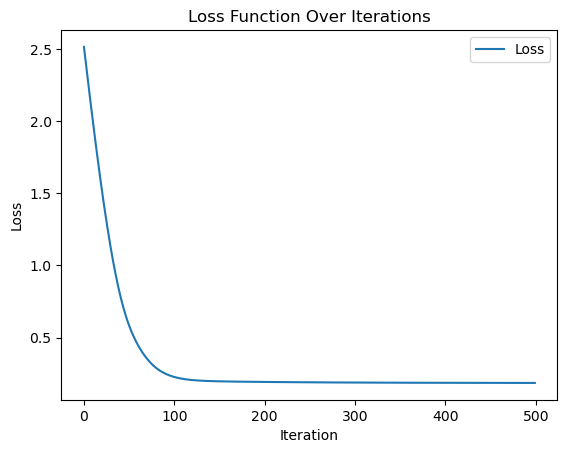

In [104]:
import tensorflow as tf
import numpy as np
from math import sqrt, pi, exp

# Cargamos los datos
df = pd.read_csv('multi_class_classification.csv')
X = df.iloc[:, :2].to_numpy()
y = df['Y'].to_numpy()

# Convertimos el vector de variables independientes y la variable dependiente en un Tensor de TensorFlow.
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

# Inicialicamos los parámetros del modelo (beta coefficients)
beta = tf.Variable(tf.random.normal([3, 3], dtype=tf.float32))

#beta = tf.Variable([[]], dtype=tf.float32)
#beta = tf.Variable(tf.reshape(beta, [5, 1])) 

# Definimos el optimizador. En este caso, usamos el Adam.
# optimizer = tf.optimizers.RMSprop(learning_rate=0.2/0.18)  FUNCIONA
optimizer = tf.optimizers.Adam(learning_rate=0.01)  

#Función para calcular la función de densidad de probabilidad.
def norm_prob(X_tf,beta):
    
    mu = beta[0] + tf.matmul(X_tf, beta[1:])
    
    prob = tf.exp(mu)/tf.reduce_sum (tf.exp(mu),axis=1, keepdims=True)
    
    return prob

# Definimos la función objetivo. En este caso, queremos maximizar la verosimilitud, luego minimizamos el logaritmo de la menos verosimilitud.
def loss_fn():
    
    # Calculamos las probabilidades con norm_prob
    probabilities = norm_prob(X_tf, beta)
    
    # Generamos el one-hot encoding de las clases
    y_one_hot = tf.one_hot(tf.cast(y_tf, tf.int32), depth=3)
    
    # Seleccionamos las probabilidades correspondientes a las clases correctas
    true_class_probs = tf.reduce_sum(probabilities * y_one_hot, axis=1)
    
    # Calculamos la pérdida como el logaritmo negativo de las probabilidades correctas
    loss = - tf.reduce_mean(tf.math.log(true_class_probs + 1e-9)) # Evitar log(0)
    
    return loss

# Store the loss values for plotting
loss_values = []

# Run optimization for a few iterations
num_iterations = 500
for i in range(num_iterations):
    with tf.GradientTape() as tape:
        # Compute the loss
        loss = loss_fn()
        
        # Compute gradients of x and y with respect to the loss
        gradients = tape.gradient(loss, [beta]) 
        # Apply gradients to update x.
        optimizer.apply_gradients(zip(gradients, [beta]))
        
        # Store the loss values for the graph
        loss_values.append(loss.numpy())

        # Print the current values of x, y, and the loss
        #if i % 10 == 0:
           # print(f"Iteration {i}: beta_0 = {beta[0].numpy()}, beta_1 = {beta[1].numpy()}, beta_2 = {beta[2].numpy()},beta_3 = {beta[3].numpy()}, sigma^2 = {beta[4].numpy()}, loss = {loss.numpy()}")

#tf_trajectory = np.array(tf_trajectory)
print(f"Final model coefficients (beta):\n{beta.numpy()}")
print(f"Final loss:{loss.numpy()}")

# Plot the loss function values over iterations
plt.plot(range(num_iterations), loss_values, label="Loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.legend()
plt.show()

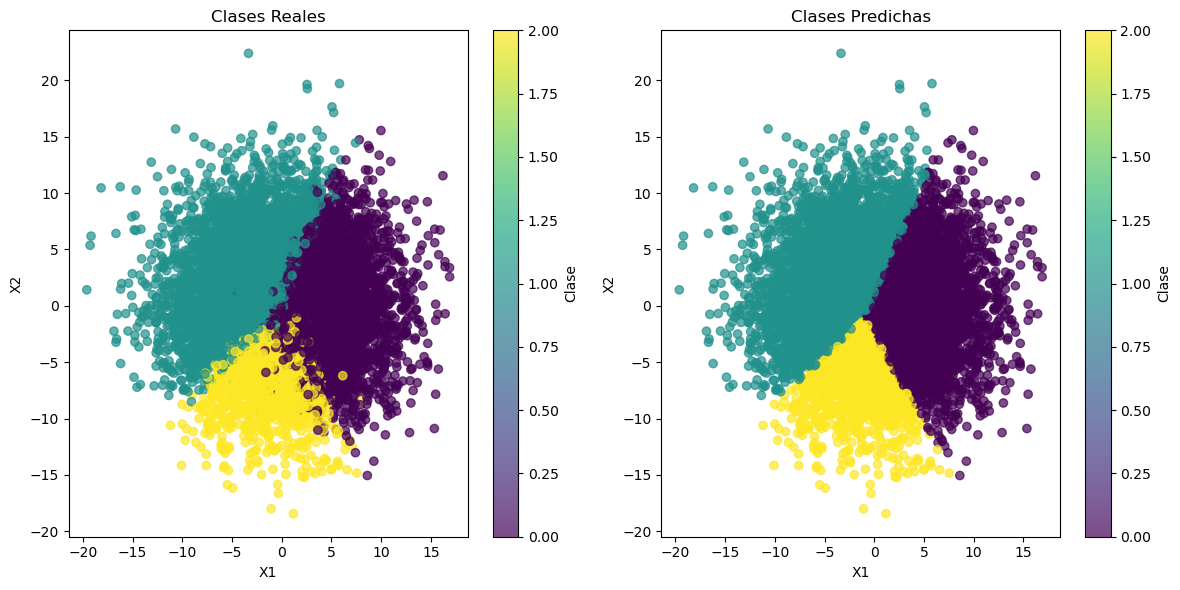

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular las probabilidades y predicciones del modelo
predicted_probs = norm_prob(X_tf, beta)
predicted_classes = tf.argmax(predicted_probs, axis=1).numpy()

# Convertir las etiquetas reales a enteros para graficar
true_classes = y.astype(int)

# Gráfico de los datos originales con las predicciones
plt.figure(figsize=(12, 6))

# Gráfico de las clases reales
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X[:, 0], X[:, 1], c=true_classes, cmap='viridis', alpha=0.7)
plt.colorbar(scatter1, label="Clase")
plt.title("Clases Reales")
plt.xlabel("X1")
plt.ylabel("X2")

# Gráfico de las clases predichas
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X[:, 0], X[:, 1], c=predicted_classes, cmap='viridis', alpha=0.7)
plt.colorbar(scatter2, label="Clase")
plt.title("Clases Predichas")
plt.xlabel("X1")
plt.ylabel("X2")

plt.tight_layout()
plt.show()

## TASK 3

**Objective:** Implement the Metropolis-Hastings algorithm to sample from a multimodal target distribution.

**Statement**

1. Define a target distribution $ p(x) $ proportional to 
   $$
   \exp\left(-\frac{x^2}{2}\right) \cdot \cos^2(5x),
   $$
   which is multimodal and difficult to sample from directly.

2. Implement the Metropolis-Hastings algorithm using a normal proposal distribution 
   $$
   q(x'|x) = \mathcal{N}(x'; x, \sigma^2)
   $$
   with $ \sigma = 0.5 $.

3. Generate 50,000 samples from the target distribution.

4. Plot the histogram of the sampled values and overlay the (normalized) target density function for comparison.


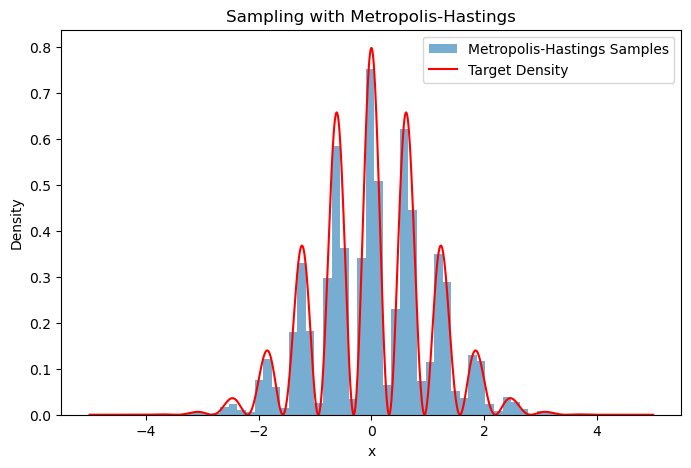

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Define the unnormalized target distribution
def target_density(x):
    return np.exp(-x**2 / 2) * ((np.cos(5*x))**2)

# Metropolis-Hastings sampler
def metropolis_hastings(target_density, n_samples=50000, proposal_sd=0.5):
    samples = []
    x = np.random.uniform(-5, 5)  # Initial state
    for _ in range(n_samples):
        x_proposed = np.random.normal(x, proposal_sd)
        acceptance_ratio = min(1, target_density(x_proposed) / target_density(x))
        if np.random.uniform(0, 1) < acceptance_ratio:
            x = x_proposed
        samples.append(x)
    return np.array(samples)

# Generate samples
samples = metropolis_hastings(target_density)

# Plot the results
x = np.linspace(-5, 5, 1000)
normalized_density = target_density(x) / np.trapz(target_density(x), x) # Usa la regla del trapezoide (método numérico) para aproximar la 
                                                                        # integral de la función  \text{target\_density}(x)  en el rango [-5, 5].

plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6, label="Metropolis-Hastings Samples")
plt.plot(x, normalized_density, label="Target Density", color="red")
plt.title("Sampling with Metropolis-Hastings")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()


## TASK 4

**Objective:** Use Monte Carlo methods to estimate the value of a definite integral that is difficult to compute analytically.

**Statement**

**Task:**

1. Estimate the value of the integral:
   $$
   I = \int_0^2 \frac{1}{1 + x^4} \, dx
   $$
   using Monte Carlo simulation.

2. Implement a Python program that:
   - Generates $ N $ random samples uniformly distributed between 0 and 2.
   - Evaluates the function $ f(x) = \frac{1}{1 + x^4} $ at these sample points.
   - Computes the average value of $ f(x) $ and multiplies it by the interval length to estimate the integral.

3. Vary $ N $ to observe how the estimation improves with more samples.

4. Compare your estimates with the actual value obtained using numerical integration (e.g., using `scipy.integrate.quad`).

5. Plot the estimation error versus the number of samples on a log-log scale to visualize the convergence rate.


Estimated integral: 1.0774
Estimated integral with quad: 1.0701


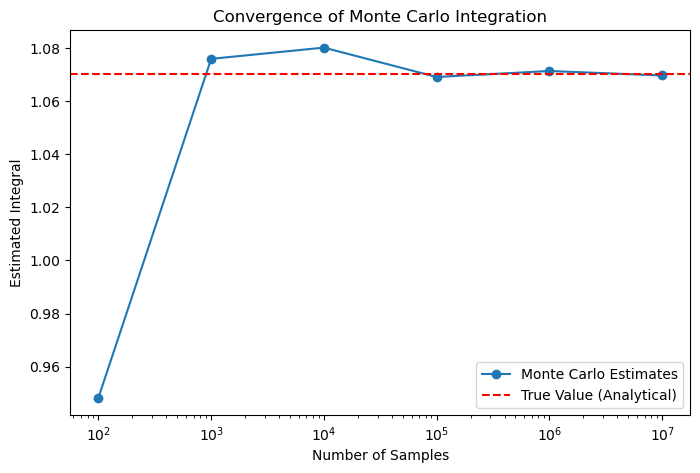

In [52]:
# Monte Carlo sampling
n_samples = 10000
x = np.random.uniform(0, 2, n_samples)
integral_estimate = np.mean(1/(1+x**4))*2
print(f"Estimated integral: {integral_estimate:.4f}")

def f(x):
    return 1 / (1 + x**4)


analytical_value, _ = quad(f, 0, 2)
print(f"Estimated integral with quad: {analytical_value:.4f}")

# Visualize convergence
sample_sizes = [100, 1000, 10000, 100000, 1000000, 10000000]
estimates = []

for n in sample_sizes:
    x = np.random.uniform(0, 2, n)
    estimates.append(np.mean(1/(1+x**4))*2)

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, estimates, marker='o', label="Monte Carlo Estimates")
plt.axhline(analytical_value, color='r', linestyle='--', label="True Value (Analytical)")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Number of Samples")
plt.ylabel("Estimated Integral")
plt.title("Convergence of Monte Carlo Integration")
plt.legend()
plt.show()


## TASK 5

**Objective:** Use Gaussian Processes with combined kernels to model a complex function that exhibits multiple patterns, such as a linear trend, periodicity, and local variations.

**Statement**

**Task:**

1. **Function to Model:**
   - Generate synthetic data from the function:
     $$
     f(x) = 0.5x + \sin\left(\frac{2\pi x}{5}\right) + \exp(-0.1x) \cdot \epsilon(x)
     $$
     where $ \epsilon(x) $ is a small noise term from a standard normal distribution.

2. **Kernel Design:**
   - Design a composite kernel that captures:
     - A linear trend (use a Linear kernel).
     - Periodic behavior (use a Periodic kernel).
     - Local variations (use a Squared Exponential kernel).
   - Combine these kernels appropriately to model the function.

3. **Implement GP Regression:**
   - Implement Gaussian Process regression using the combined kernel.
   - Optimize the hyperparameters of the combined kernel using the marginal likelihood.

4. **Visualization:**
   - Plot the training data and the GP predictive mean.
   - Include the 95% confidence intervals.
   - Discuss how each component of the kernel contributes to modeling the function.


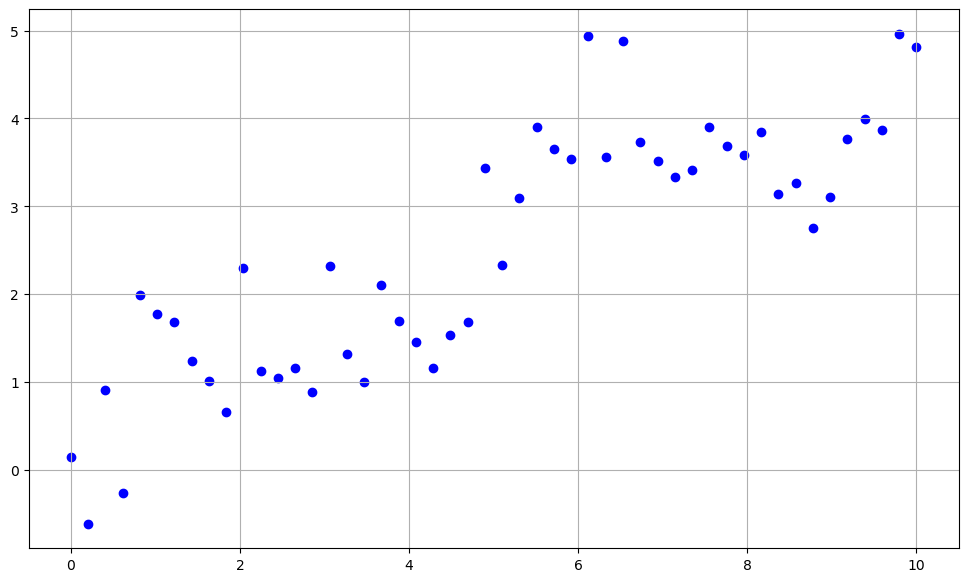

In [118]:
## Generate Synthetic data from the function:...

# Generate synthetic data with periodic and decaying behavior
def f(x):
    return 0.5 * x + np.sin(2 * np.pi * x / 5) 

# Training data
X_train = np.linspace(0, 10, 50)
y_train = f(X_train) + np.exp(-0.1*X_train)*np.random.normal(0, 1, size=X_train.shape)

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.grid(True)
plt.scatter(X_train, y_train, color='blue', label='Training Data')

In [120]:
# Define the custom kernel
def custom_kernel(x1, x2, sigma_f=1.0, ell=1.0, p=5.0, sigma_b=0.0, sigma_v = 1.0, c=0):
    """Custom kernel: Decaying periodic kernel."""
    # Periodic Kernel
    sin_sq = np.sin(np.pi * np.subtract.outer(x1, x2) / p) ** 2
    K_periodic = sigma_f**2 * np.exp (-2 * sin_sq / ell**2)

    #RBF
    sqdist = np.subtract.outer(x1, x2)**2
    K_RBF = sigma_f**2 * np.exp(-0.5 * sqdist / ell**2)

    #Linear Kernel
    K_linear = sigma_b**2 + sigma_v**2 * np.outer(x1-c, x2-c)
    
    # Combined Kernel (Multiplication)
    return (K_periodic + K_linear) * K_RBF

In [122]:
## Implement GP regression
from scipy.optimize import minimize

# Define log marginal likelihood function
def log_marginal_likelihood(theta):
    """Compute the log marginal likelihood for given hyperparameters."""
    sigma_f, ell, sigma_n, p, sigma_b, sigma_v, c = theta
    K = custom_kernel(X_train, X_train, sigma_f, ell, p, sigma_b, sigma_v, c) + sigma_n**2 * np.eye(len(X_train))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return np.inf  # Return infinity if K is not positive definite
    
    # Solve for alpha: K * alpha = y
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    
    # Compute the log marginal likelihood
    log_likelihood = -0.5 * y_train.T @ alpha
    log_likelihood -= np.sum(np.log(np.diag(L)))
    log_likelihood -= len(X_train) / 2 * np.log(2 * np.pi)
    
    # We return the negative log marginal likelihood for minimization
    return -log_likelihood

# Define the prior penalty function
def prior_penalty(theta):
    sigma_f, ell, sigma_n, p, sigma_b, sigma_v, c  = theta
    # Assume prior means and variances
    mu_sigma_f, mu_ell, mu_sigma_n, mu_p, mu_sigma_b, mu_sigma_v, mu_c = 1.0, 1.0, 0.5, 5.0, 0.0, 1.0, 0.0 
    sigma_sigma_f, sigma_ell, sigma_sigma_n, sigma_p, sigma_sigma_b, sigma_sigma_v, sigma_c = 0.5, 0.5, 0.2, 0.5, 0.05, 0.5,  0.05
    # Negative log prior probabilities (penalties)
    penalty = (
        0.5 * ((sigma_f - mu_sigma_f) / sigma_sigma_f) ** 2 +
        0.5 * ((ell - mu_ell) / sigma_ell) ** 2 +
        0.5 * ((sigma_n - mu_sigma_n) / sigma_sigma_n) ** 2 +
        0.5 * ((p - sigma_p) / sigma_p) ** 2 +
        0.5 * ((sigma_b - sigma_sigma_b) / sigma_sigma_b) ** 2 +
        0.5 * ((sigma_v - sigma_sigma_v) / sigma_sigma_v) ** 2 +
        0.5 * ((c - sigma_c) / sigma_c) ** 2 
        
    )
    return penalty

# Modify the log marginal likelihood to include the prior penalty
def log_marginal_likelihood_with_prior(theta):
    
    lml = log_marginal_likelihood(theta)
    penalty = prior_penalty(theta)
    return lml + penalty  # Add penalty to the negative log marginal likelihood

# Modify the log marginal likelihood to include the prior penalty
def log_marginal_likelihood_with_prior(theta):
    # Your code here
    lml = log_marginal_likelihood(theta)
    penalty = prior_penalty(theta)
    return lml + penalty  # Add penalty to the negative log marginal likelihood

# Initial guesses for hyperparameters
initial_theta = [1.0, 1.0, 0.5, 5.0, 0.0,1.0, 0.0]  # sigma_f, ell, sigma_n, p, sigma_b, sigma_v, c

# Bounds for hyperparameters
bounds = ((1e-2, 5.0), (1e-2, 5.0), (1e-2, 1.0), (1e-2,20.0), (1e-2,5.0), (1e-2,5.0), (1e-2,5.0))


# Optimize
result = minimize(
    fun = log_marginal_likelihood_with_prior,
    x0 = initial_theta,
    bounds = bounds,
    method = 'L-BFGS-B'
)

# Extract optimized hyperparameters and retrain GP
sigma_f_opt, ell_opt, sigma_n_opt, p_opt, sigma_b_opt, sigma_v_opt, c_opt = result.x
print(f"Optimized sigma_f: {sigma_f_opt}")
print(f"Optimized ell: {ell_opt}")
print(f"Optimized sigma_n: {sigma_n_opt}")
print(f"Optimized p: {p_opt}")
print(f"Optimized sigma_b: {sigma_b_opt}")
print(f"Optimized sigma_v: {sigma_v_opt}")
print(f"Optimized c: {c_opt}")



Optimized sigma_f: 0.5581901830372924
Optimized ell: 1.829908448201913
Optimized sigma_n: 0.5561046207652812
Optimized p: 0.8948671677483573
Optimized sigma_b: 0.05005427265195536
Optimized sigma_v: 0.7687593197064372
Optimized c: 0.046639978805392404


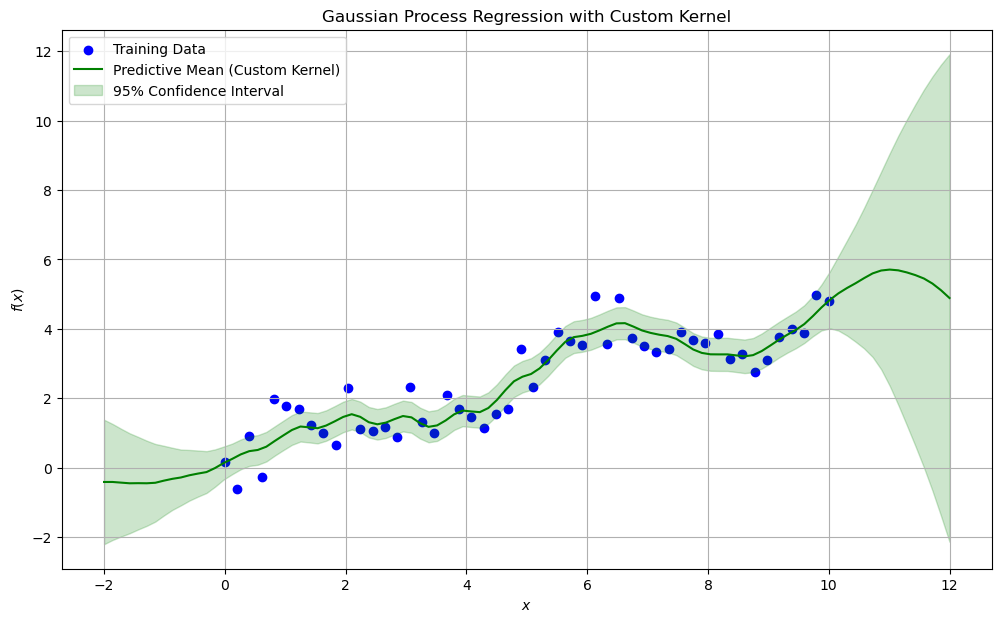

In [126]:
# Test inputs
X_test = np.linspace(-2, 12, 100)

# Compute covariance matrices
K_custom = custom_kernel(X_train, X_train, sigma_f_opt, ell_opt, p_opt, sigma_b_opt, sigma_v_opt,c_opt)
K_custom += sigma_n_opt**2 * np.eye(len(X_train))
K_s_custom = custom_kernel(X_train, X_test, sigma_f_opt, ell_opt, p_opt, sigma_b_opt, sigma_v_opt,c_opt)
K_ss_custom = custom_kernel(X_test, X_test, sigma_f_opt, ell_opt, p_opt, sigma_b_opt, sigma_v_opt,c_opt)
K_inv_custom = np.linalg.inv(K_custom)

# Compute the posterior predictive mean and covariance
mu_s_custom = K_s_custom.T @ K_inv_custom @ y_train
cov_s_custom = K_ss_custom - K_s_custom.T @ K_inv_custom @ K_s_custom

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s_custom, color='green', label='Predictive Mean (Custom Kernel)')

# Plot the confidence intervals
stdv_custom = np.sqrt(np.diag(cov_s_custom))
plt.fill_between(
    X_test,
    mu_s_custom - 1.96 * stdv_custom,
    mu_s_custom + 1.96 * stdv_custom,
    alpha=0.2,
    color='green',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression with Custom Kernel')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()
